# LDA Baseline Model
**Modeling**

Implements a Latent Dirichlet Allocation (LDA) baseline following the CRISP-DM modeling phase.  
Input: page-level token lists produced by `src/utils.py`.  
Granularity: one document = one slide page (≥ 10 tokens after preprocessing).

**Structure:**
1. Setup & Data Loading
2. Corpus Preparation (dictionary + BoW)
3. Model Training
4. Topic Inspection
5. Evaluation (Coherence & Perplexity)

---
## 1. Setup & Data Loading

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# make src/ importable from within notebooks/
_nb_dir = os.path.dirname(os.path.abspath('lda.ipynb'))
_src_dir = os.path.abspath(os.path.join(_nb_dir, '..'))
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)

warnings.filterwarnings('ignore')

# plotting style
plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'font.family'      : 'serif',
})
PALETTE = ['#2C5F8A', '#4C9BE8', '#A8C8E8', '#D9E8F5']

print('Libraries loaded.')

Libraries loaded.


In [2]:
from utils import load_corpus, tokenize_corpus, build_slide_page_docs

# load and tokenise
corpus = tokenize_corpus(load_corpus())

# aggregate to page level; drop pages with fewer than 10 tokens
MIN_TOKENS = 10
docs = build_slide_page_docs(corpus)
docs = docs[docs['n_tokens'] >= MIN_TOKENS].reset_index(drop=True)

print(f'Documents (pages): {len(docs)}')
print(f'Token count — min: {docs.n_tokens.min()}, median: {docs.n_tokens.median():.0f}, max: {docs.n_tokens.max()}')
docs.head()

Dropping 4 empty pages after tokenisation.


Documents (pages): 127
Token count — min: 10, median: 23, max: 80


,source_file,page,tokens,n_tokens
0,icd_1_v1_cleaned_v7.csv,5,"[logístico, conteúdo, informação, plataforma, ...",24
1,icd_1_v1_cleaned_v7.csv,6,"[unidade, curricular, objetivo, contacto, ciên...",47
2,icd_1_v1_cleaned_v7.csv,7,"[processo, pedagógico, aplicação, prático, est...",27
3,icd_1_v1_cleaned_v7.csv,8,"[sucesso, capaz, necessidade, existência, prát...",34
4,icd_1_v1_cleaned_v7.csv,9,"[avaliação, avaliação, periódico, modalidade, ...",33


---
## 2. Corpus Preparation

In [3]:
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel

RANDOM_SEED = 42

texts = docs['tokens'].tolist()

# build dictionary — filter extremes to reduce noise
# no_below: ignore terms appearing in fewer than 2 documents
# no_above: ignore terms appearing in more than 80% of documents
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=2, no_above=0.8)
dictionary.compactify()

bow_corpus = [dictionary.doc2bow(text) for text in texts]

print(f'Vocabulary size (after filtering): {len(dictionary)}')
print(f'Corpus size: {len(bow_corpus)} documents')

Vocabulary size (after filtering): 433
Corpus size: 127 documents


---
## 3. Model Training

In [4]:
from gensim.models import LdaModel

NUM_TOPICS  = 8  
PASSES      = 20
ITERATIONS  = 400
ALPHA       = 'auto'  
ETA         = 'auto'

lda = LdaModel(
    corpus           = bow_corpus,
    id2word          = dictionary,
    num_topics       = NUM_TOPICS,
    passes           = PASSES,
    iterations       = ITERATIONS,
    alpha            = ALPHA,
    eta              = ETA,
    random_state     = RANDOM_SEED,
    per_word_topics  = True,
)

print(f'LDA trained: {NUM_TOPICS} topics, {PASSES} passes, seed={RANDOM_SEED}')

LDA trained: 8 topics, 20 passes, seed=42


---
## 4. Topic Inspection

In [5]:
# top terms per topic
TOP_N = 10
for i, topic in lda.print_topics(num_topics=NUM_TOPICS, num_words=TOP_N):
    print(f'Topic {i:02d}: {topic}')

Topic 00: 0.087*"modelo" + 0.030*"dado" + 0.028*"resultado" + 0.017*"processo" + 0.017*"objetivo" + 0.016*"avaliação" + 0.015*"classificação" + 0.014*"direito" + 0.014*"extração" + 0.014*"confusão"
Topic 01: 0.052*"dado" + 0.029*"valores" + 0.027*"modelo" + 0.021*"resultado" + 0.019*"omisso" + 0.019*"tratamento" + 0.019*"data" + 0.016*"conjunto" + 0.014*"treino" + 0.013*"aprendizagem"
Topic 02: 0.070*"data" + 0.033*"dado" + 0.025*"taxa" + 0.021*"modelo" + 0.017*"model" + 0.017*"estudante" + 0.017*"objetivo" + 0.013*"modeling" + 0.013*"desempenho" + 0.013*"business"
Topic 03: 0.054*"variável" + 0.036*"regressão" + 0.034*"features" + 0.031*"dado" + 0.027*"categórico" + 0.022*"atributo" + 0.022*"target" + 0.018*"fit" + 0.018*"árvore" + 0.018*"classificação"
Topic 04: 0.137*"dado" + 0.025*"informação" + 0.018*"conhecimento" + 0.016*"data" + 0.016*"cluster" + 0.016*"ciência" + 0.011*"conjunto" + 0.011*"distância" + 0.011*"contexto" + 0.010*"atributo"
Topic 05: 0.065*"dado" + 0.031*"visualiz

In [6]:

# topic summary table — top terms + interpretive label 
TOPIC_LABELS = {
    0: 'Clustering & Visualização',
    1: 'IA Generativa & Padrões',
    2: 'Fundamentos de Data Science',
    3: 'Processo de Modelação',
    4: 'Aprendizagem Supervisionada',
    5: 'Deteção de Anomalias',
    6: 'Predição & Treino',
    7: 'Pré-processamento & Valores Omissos',
}

rows = []
for i in range(NUM_TOPICS):
    terms = lda.show_topic(i, topn=TOP_N)
    top_words   = ', '.join(w for w, _ in terms)
    top_weights = [round(p, 3) for _, p in terms]
    rows.append({
        'Topic': f'T{i:02d}',
        'Label': TOPIC_LABELS[i],
        'Top 10 Terms': top_words,
        'Max weight': max(top_weights),
    })

topic_df = pd.DataFrame(rows).set_index('Topic')

topic_df.style \
    .set_caption('LDA Topics — Top 10 Terms per Topic') \
    .set_properties(**{'text-align': 'left'}) \
    .bar(subset=['Max weight'], color='#A8C8E8', vmin=0, vmax=0.15)


,Label,Top 10 Terms,Max weight
Topic,,,
T00,Clustering & Visualização,"modelo, dado, resultado, processo, objetivo, avaliação, classificação, direito, extração, confusão",0.087000
T01,IA Generativa & Padrões,"dado, valores, modelo, resultado, omisso, tratamento, data, conjunto, treino, aprendizagem",0.052000
T02,Fundamentos de Data Science,"data, dado, taxa, modelo, model, estudante, objetivo, modeling, desempenho, business",0.070000
T03,Processo de Modelação,"variável, regressão, features, dado, categórico, atributo, target, fit, árvore, classificação",0.054000
T04,Aprendizagem Supervisionada,"dado, informação, conhecimento, data, cluster, ciência, conjunto, distância, contexto, atributo",0.137000
T05,Deteção de Anomalias,"dado, visualização, informação, data, problema, objetivo, cliente, volume, business, technique",0.065000
T06,Predição & Treino,"dado, outlier, valores, identificação, análise, padrão, modelo, outliers, inicial, comum",0.064000
T07,Pré-processamento & Valores Omissos,"dado, variável, processo, numérico, categórico, aluno, transformação, atributo, correlação, valores",0.079000


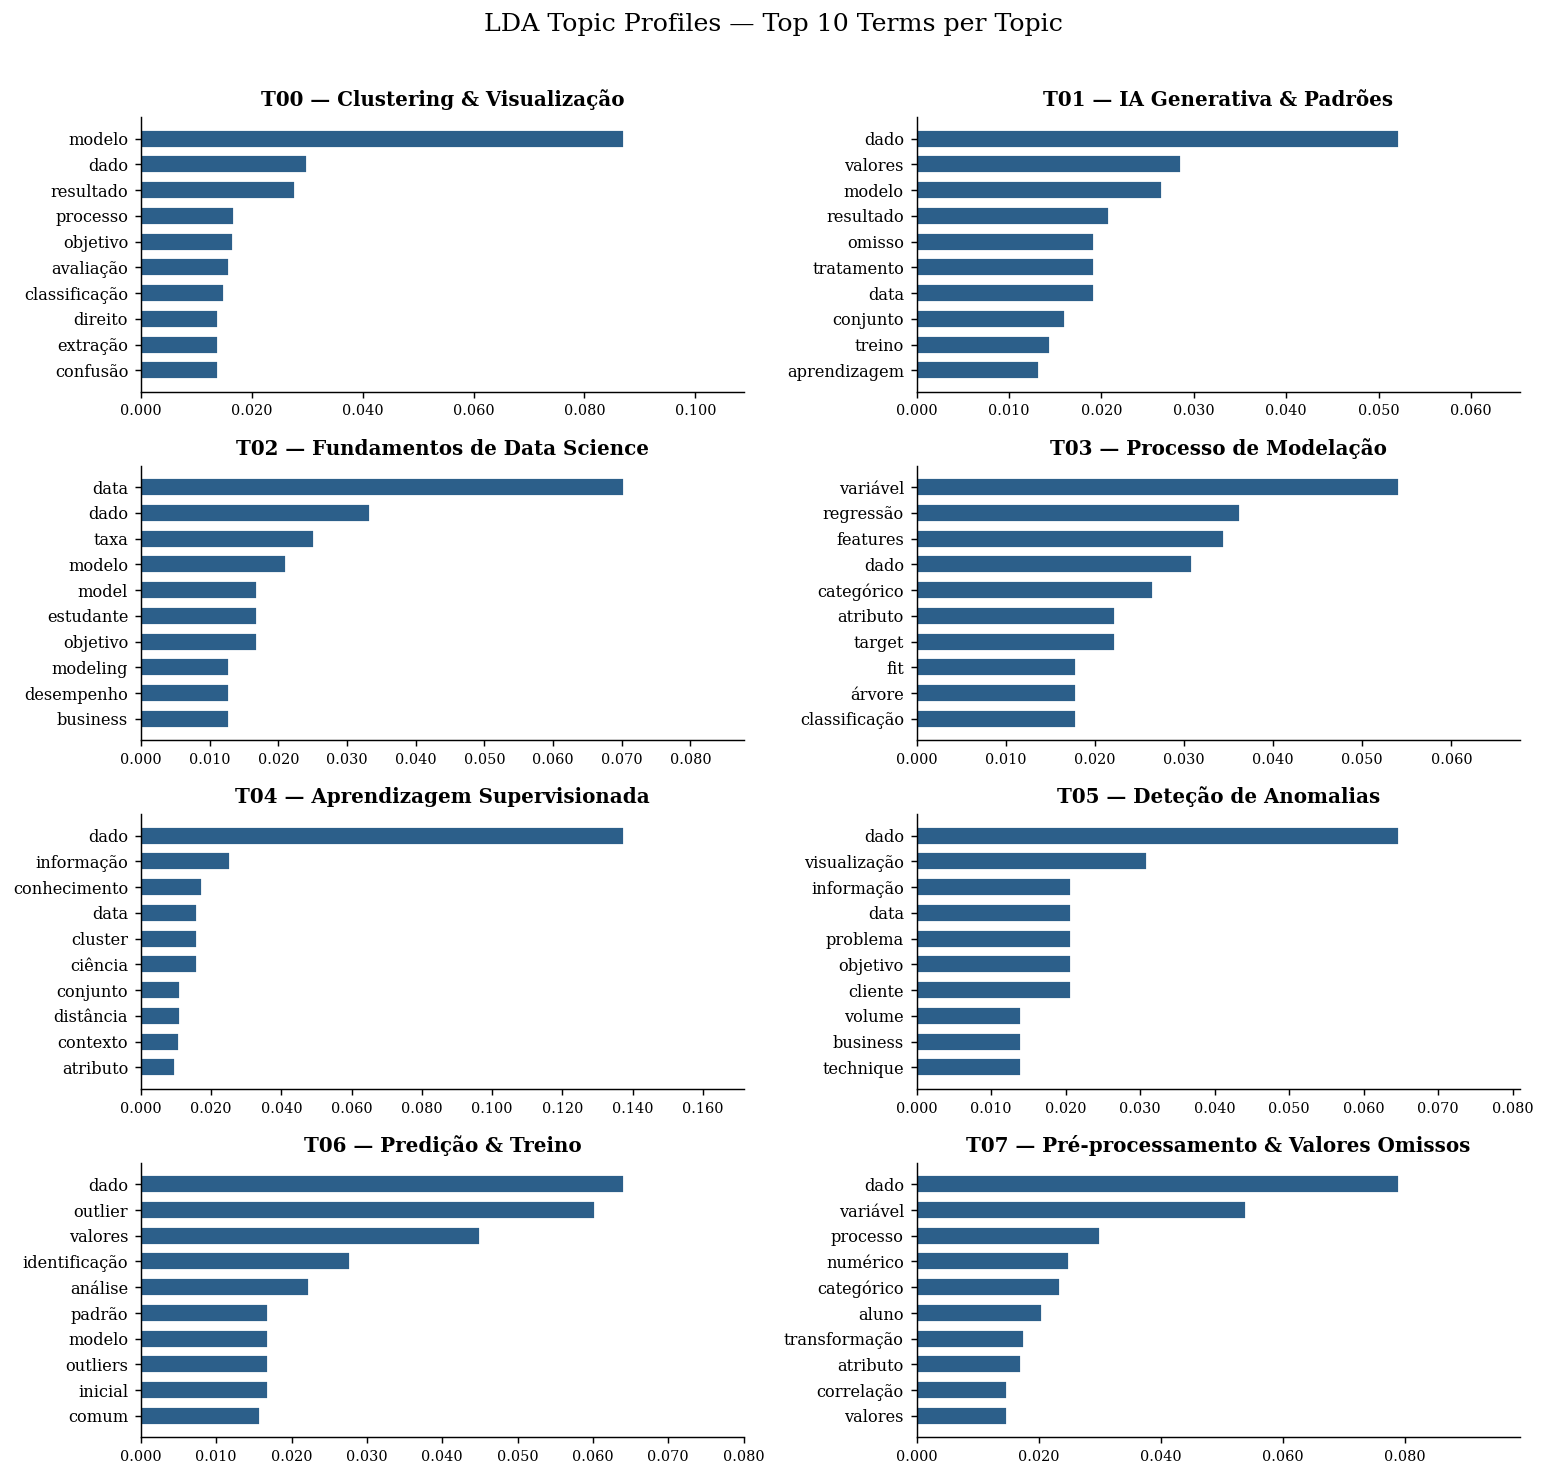

In [7]:
TOP_VIS = 10
n_cols = 2
n_rows = (NUM_TOPICS + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 2.8))
axes = axes.flatten()

for i in range(NUM_TOPICS):
    terms = lda.show_topic(i, topn=TOP_VIS)
    words   = [w for w, _ in terms][::-1]
    weights = [p for _, p in terms][::-1]

    ax = axes[i]
    bars = ax.barh(words, weights, color=PALETTE[0], edgecolor='white', height=0.7)
    ax.set_title(f'T{i:02d} — {TOPIC_LABELS[i]}', fontsize=11, fontweight='bold')
    ax.set_xlim(0, max(weights) * 1.25)
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# hide unused subplots
for j in range(NUM_TOPICS, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('LDA Topic Profiles — Top 10 Terms per Topic', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


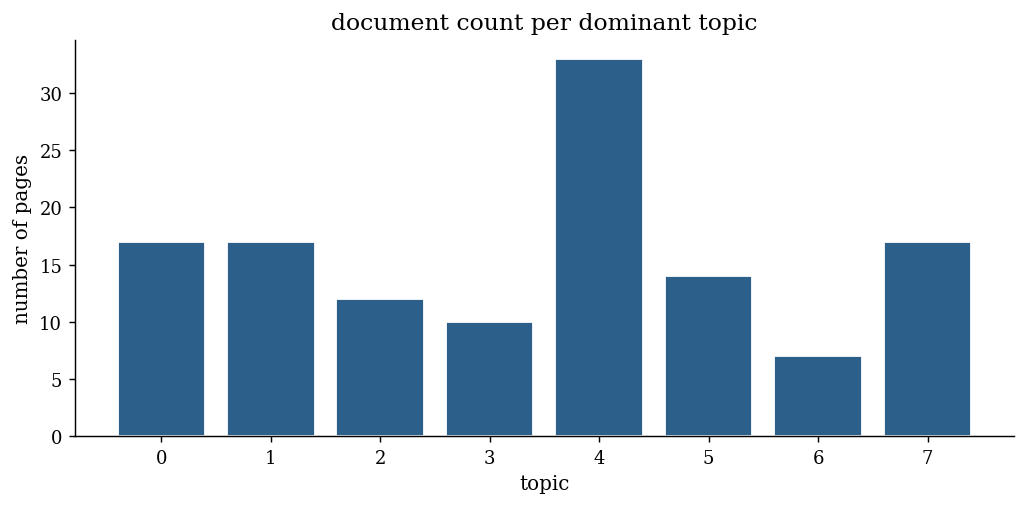

In [8]:
# dominant topic per document
def dominant_topic(bow):
    topics = lda.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

docs = docs.copy()
docs['dominant_topic'] = [dominant_topic(b) for b in bow_corpus]

topic_dist = docs['dominant_topic'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(topic_dist.index, topic_dist.values, color=PALETTE[0], edgecolor='white')
ax.set_xlabel('topic')
ax.set_ylabel('number of pages')
ax.set_title('document count per dominant topic')
ax.set_xticks(range(NUM_TOPICS))
plt.tight_layout()
plt.show()

---
## 5. Evaluation

In [9]:
# coherence score (C_v) for the current model
coherence_model = CoherenceModel(
    model=lda,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v',
)
coherence_cv = coherence_model.get_coherence()
perplexity   = lda.log_perplexity(bow_corpus)

print(f'Coherence (C_v) : {coherence_cv:.4f}  (higher is better, target > 0.50)')
print(f'Perplexity (log): {perplexity:.4f}   (lower is better)')

Coherence (C_v) : 0.3570  (higher is better, target > 0.50)
Perplexity (log): -5.8115   (lower is better)


k= 3  C_v=0.3287
k= 4  C_v=0.3749
k= 5  C_v=0.3667
k= 6  C_v=0.3472
k= 7  C_v=0.3826
k= 8  C_v=0.3570
k= 9  C_v=0.3522
k=10  C_v=0.3490
k=11  C_v=0.3370
k=12  C_v=0.3518
k=13  C_v=0.3769
k=14  C_v=0.3790
k=15  C_v=0.3965


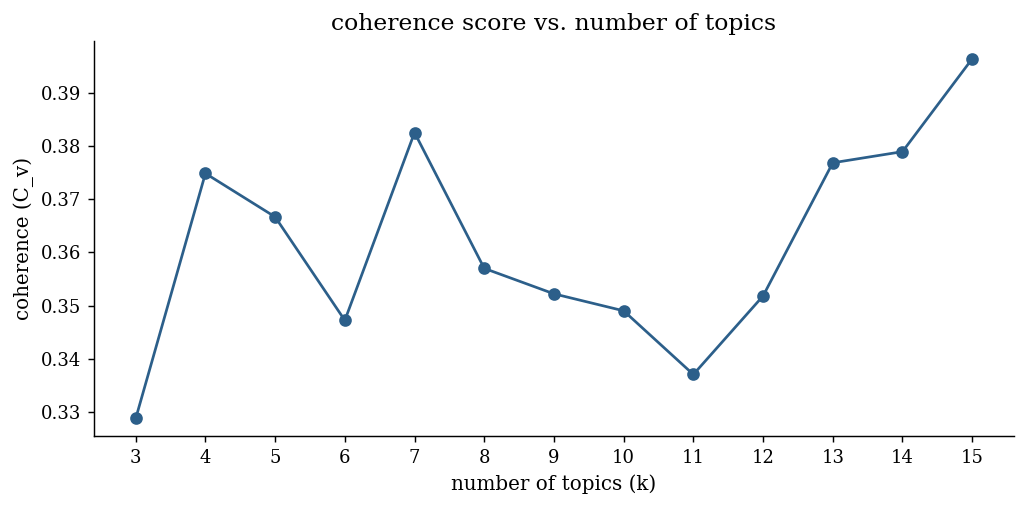


Best k=15  C_v=0.3965


In [10]:
# coherence grid search over number of topics
# run this to find the optimal K before committing to a final model
TOPIC_RANGE = range(3, 16)

results = []
for k in TOPIC_RANGE:
    m = LdaModel(
        corpus       = bow_corpus,
        id2word      = dictionary,
        num_topics   = k,
        passes       = PASSES,
        iterations   = ITERATIONS,
        alpha        = ALPHA,
        eta          = ETA,
        random_state = RANDOM_SEED,
    )
    cv = CoherenceModel(model=m, texts=texts, dictionary=dictionary, coherence='c_v').get_coherence()
    results.append({'k': k, 'coherence_cv': round(cv, 4)})
    print(f'k={k:2d}  C_v={cv:.4f}')

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df['k'], results_df['coherence_cv'], marker='o', color=PALETTE[0])
ax.set_xlabel('number of topics (k)')
ax.set_ylabel('coherence (C_v)')
ax.set_title('coherence score vs. number of topics')
ax.set_xticks(list(TOPIC_RANGE))
plt.tight_layout()
plt.show()

best = results_df.loc[results_df['coherence_cv'].idxmax()]
print(f'\nBest k={int(best.k)}  C_v={best.coherence_cv}')